In [8]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [10]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    plot_training_curves,
    plot_ytrue_vs_ypred,
    compare_models_for_cell,
    compare_r2_across_cells,  # improved version with sort_by
    compare_models_pairwise_r2,
    journal_plot_pack,  # improved version
    plot_r2_comparison_boxplot,  # NEW
    plot_r2_histogram,  # NEW
    plot_covariate_trial,  # NEW
    COVARIATE_NAMES_SIMULATED,  # NEW — 5-covariate version
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [11]:
BASE_MODEL_DIR = "../resources/models/simulated"
BASE_RESULTS_DIR = "../resources/results/simulated"
FORCE_EXPERIMENTS = (
    False  # set to True to re-run all experiments and overwrite existing results/models
)

filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../resources/data/simulated", filenames)

In [12]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

### Baseline models (GLM and XGBoost)

In [ ]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val pseudo-R²:         0.4740
Val log-likelihood:    2301.52
Val deviance:          6.29
Test pseudo-R²:        0.5115
Test log-likelihood:   3256.04
Test deviance:         7.41

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val pseudo-R²:         0.4718
Val log-likelihood:    2337.34
Val deviance:          6.26
Test pseudo-R²:        0.5064
Test log-likelihood:   3052.80
Test deviance:         7.29

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val pseudo-R²:         0.4556
Val log-likelihood:    2273.83
Val deviance:          6.49
Test pseudo-R²:        0.5150
Test log-likelihood:   2831.73
Test deviance:         6.77

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
Val pseud

In [ ]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM-NoGS",
    fit_poisson_glm,
    {"grid_search": False, "k_folds": 5, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== GLM-NoGS Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val metrics:           (not available)
Test pseudo-R²:        0.4958
Test log-likelihood:   5557.57
Test deviance:         6.85

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val metrics:           (not available)
Test pseudo-R²:        0.4913
Test log-likelihood:   5390.14
Test deviance:         6.78

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val metrics:           (not available)
Test pseudo-R²:        0.4878
Test log-likelihood:   5105.56
Test deviance:         6.63

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
Val metrics:           (not available)
Test pseudo-R²:        0.4814
Test log-likelihood:   5276.44
Test deviance:         6.95

--- Cell 4.0 ---
Train ps

In [15]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'trainer_params': 

In [ ]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8704
Train log-likelihood:  16527.43
Train deviance:        1.54
Val pseudo-R²:         0.8072
Val log-likelihood:    3198.64
Val deviance:          2.31
Test pseudo-R²:        0.7658
Test log-likelihood:   4123.80
Test deviance:         3.55

--- Cell 1.0 ---
Train pseudo-R²:       0.8721
Train log-likelihood:  16809.31
Train deviance:        1.54
Val pseudo-R²:         0.7806
Val log-likelihood:    3161.22
Val deviance:          2.60
Test pseudo-R²:        0.7638
Test log-likelihood:   3908.56
Test deviance:         3.49

--- Cell 2.0 ---
Train pseudo-R²:       0.8702
Train log-likelihood:  16600.22
Train deviance:        1.51
Val pseudo-R²:         0.7785
Val log-likelihood:    3140.46
Val deviance:          2.64
Test pseudo-R²:        0.7634
Test log-likelihood:   3611.92
Test deviance:         3.30

--- Cell 3.0 ---
Train pseudo-R²:       0.8672
Train log-likelihood:  16456.14
Train deviance:        1.56
Val p

In [ ]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost-NoGS",
    fit_poisson_xgboost,
    {"grid_search": False, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== XGBoost-NoGS Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8632
Train log-likelihood:  16436.94
Train deviance:        1.62
Val metrics:           (not available)
Test pseudo-R²:        0.7875
Test log-likelihood:   7340.95
Test deviance:         2.89

--- Cell 1.0 ---
Train pseudo-R²:       0.8604
Train log-likelihood:  16661.33
Train deviance:        1.68
Val metrics:           (not available)
Test pseudo-R²:        0.7769
Test log-likelihood:   7102.70
Test deviance:         2.97

--- Cell 2.0 ---
Train pseudo-R²:       0.8617
Train log-likelihood:  16496.34
Train deviance:        1.61
Val metrics:           (not available)
Test pseudo-R²:        0.7773
Test log-likelihood:   6792.26
Test deviance:         2.88

--- Cell 3.0 ---
Train pseudo-R²:       0.8566
Train log-likelihood:  16324.75
Train deviance:        1.69
Val metrics:           (not available)
Test pseudo-R²:        0.7819
Test log-likelihood:   7088.42
Test deviance:         2.92

--- Cell 4.0 ---
Trai

In [18]:
xgboost_results["best_params"]

{0.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
  

### Extractor factory

In [19]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS + No-GS)

In [20]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP.pkl

=== Per-Cell NN (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN.pkl

=== Per-Cell NN (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN.pkl


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


In [21]:
# Fixed hidden sizes for No-GS runs
fixed_hidden_sizes = (64, 32)

# No-grid-search versions (fixed extractor)
for name in extractor_names:
    print(f"\n=== Per-Cell NN (No GS) with {name} extractor ===")

    # Build extractor using the new unified interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: use hidden_sizes directly in the model
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: fixed extractor, no grid search
        kwargs = {
            "batch_size": "auto",
            "model_param_grid": {
                "extractor": extractor,
                "hidden_sizes": [None],
            },
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-PerCell-{name}-NoGS",
        fit_poisson_nn,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["NoGS"] = res


=== Per-Cell NN (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP-NoGS.pkl

=== Per-Cell NN (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN-NoGS.pkl

=== Per-Cell NN (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN-NoGS.pkl


In [22]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [23]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-MLP.pkl

=== TL DeepSharedShallowHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-CNN.pkl

=== TL DeepSharedShallowHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-RNN.pkl


In [24]:
# Fixed hidden sizes for No-GS TL run
fixed_hidden_sizes = (256, 128)

# Shared hidden: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses hidden_sizes directly
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: use extractor as shared feature extractor
        kwargs = {
            "batch_size": "auto",
            "model_params": {
                "shared_extractor": extractor,
                "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            },
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["NoGS"] = res


=== TL DeepSharedShallowHead (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-MLP-NoGS.pkl

=== TL DeepSharedShallowHead (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-CNN-NoGS.pkl

=== TL DeepSharedShallowHead (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-RNN-NoGS.pkl


### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [25]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-MLP.pkl

=== TL DeepSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-CNN.pkl

=== TL DeepSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-RNN.pkl


In [26]:
# Fixed sizes for No-GS TL DeepSharedDeepHead
fixed_shared_sizes = (256, 128)
fixed_head_sizes = (128, 64)

# Nonlinear heads: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_shared_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses shared_sizes directly
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": fixed_shared_sizes,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": None,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["NoGS"] = res


=== TL DeepSharedDeepHead (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-MLP-NoGS.pkl

=== TL DeepSharedDeepHead (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-CNN-NoGS.pkl

=== TL DeepSharedDeepHead (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-RNN-NoGS.pkl


### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [27]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": [None],  # ignored for CNN/RNN, but required for MLP
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-MLP.pkl

=== TL ShallowSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-CNN.pkl

=== TL ShallowSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-RNN.pkl


In [28]:
# Fixed sizes for No-GS TL ShallowSharedDeepHead
fixed_shared_dim = 128
fixed_head_sizes = (128, 64)

# First layer: No-GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # Shallow extractor = one layer → hidden_sizes = (shared_dim,)
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=(fixed_shared_dim,)
    )

    if extractor is None:
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": fixed_shared_dim,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": None,  # ignored for CNN/RNN, but required for MLP
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["NoGS"] = res


=== TL ShallowSharedDeepHead (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-MLP-NoGS.pkl

=== TL ShallowSharedDeepHead (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-CNN-NoGS.pkl

=== TL ShallowSharedDeepHead (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-ShallowSharedDeepHead-TL-RNN-NoGS.pkl


In [29]:
print("MLP\n", percell_results["MLP"]["GS"]["best_params"])
print("CNN\n", percell_results["CNN"]["GS"]["best_params"])
print("RNN\n", percell_results["RNN"]["GS"]["best_params"])

MLP
 {0.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 1.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 2.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 3.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 4.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 10.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 11.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 1e-05}}, 12.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 13.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 14.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 25.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lamb

In [30]:
print("MLP\n", tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'hidden_sizes': (256, 128), 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 0.0001}}
CNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05

In [31]:
print("MLP\n", tl_results["deep_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': None, 'shared_sizes': (256, 128)}, 'trainer_params': {'l1_lambda': 0.0}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
), 'shared_sizes': None}, 'trainer_params': {'l1_lambda': 1e-05}}
RNN
 {'model_params': {'head_sizes': (128, 64), 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dro

In [32]:
print("MLP\n", tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': 256, 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 0.0}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
)}, 'trainer_params': {'l1_lambda': 0.0001}}


### Build comparison lists for GS and No-GS

In [33]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [34]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,0.0,0.511454,0.765825,0.881525,0.818835,0.861255,0.579365,0.759967,0.586349,0.887030,0.896795,0.911843,0.869432,0.602533,0.889404
1,1.0,0.506373,0.763823,0.871935,0.820681,0.872139,0.570893,0.761137,0.600535,0.881888,0.899805,0.911367,0.858207,0.613671,0.883359
2,2.0,0.514983,0.763364,0.828639,0.851436,0.882372,0.601825,0.785183,0.608220,0.872274,0.891572,0.898844,0.858291,0.600423,0.880253
3,3.0,0.497466,0.759938,0.881145,0.866152,0.909692,0.598874,0.775888,0.610262,0.893690,0.909383,0.923490,0.885992,0.623278,0.893766
4,4.0,0.501561,0.756861,0.866796,0.873272,0.891721,0.577313,0.767910,0.597716,0.886538,0.899374,0.912040,0.862826,0.609293,0.883792
5,10.0,0.410530,0.704449,0.783448,0.763013,0.765939,0.503774,0.678429,0.656224,0.759938,0.784481,0.764792,0.753747,0.523337,0.750847
6,11.0,0.428756,0.716208,0.771285,0.774863,0.765846,0.509285,0.672498,0.652448,0.768647,0.786948,0.776293,0.761755,0.501289,0.762293
7,12.0,0.467753,0.727279,0.794835,0.770807,0.783796,0.538603,0.713179,0.665697,0.770924,0.788338,0.783556,0.778112,0.447120,0.761088
8,13.0,0.448820,0.718115,0.801722,0.773750,0.796018,0.527534,0.712971,0.653767,0.773160,0.794910,0.780735,0.773561,0.460381,0.760875
9,14.0,0.425786,0.684994,0.754625,0.734952,0.767167,0.528304,0.680127,0.658981,0.746045,0.767725,0.761782,0.734132,0.498997,0.734357


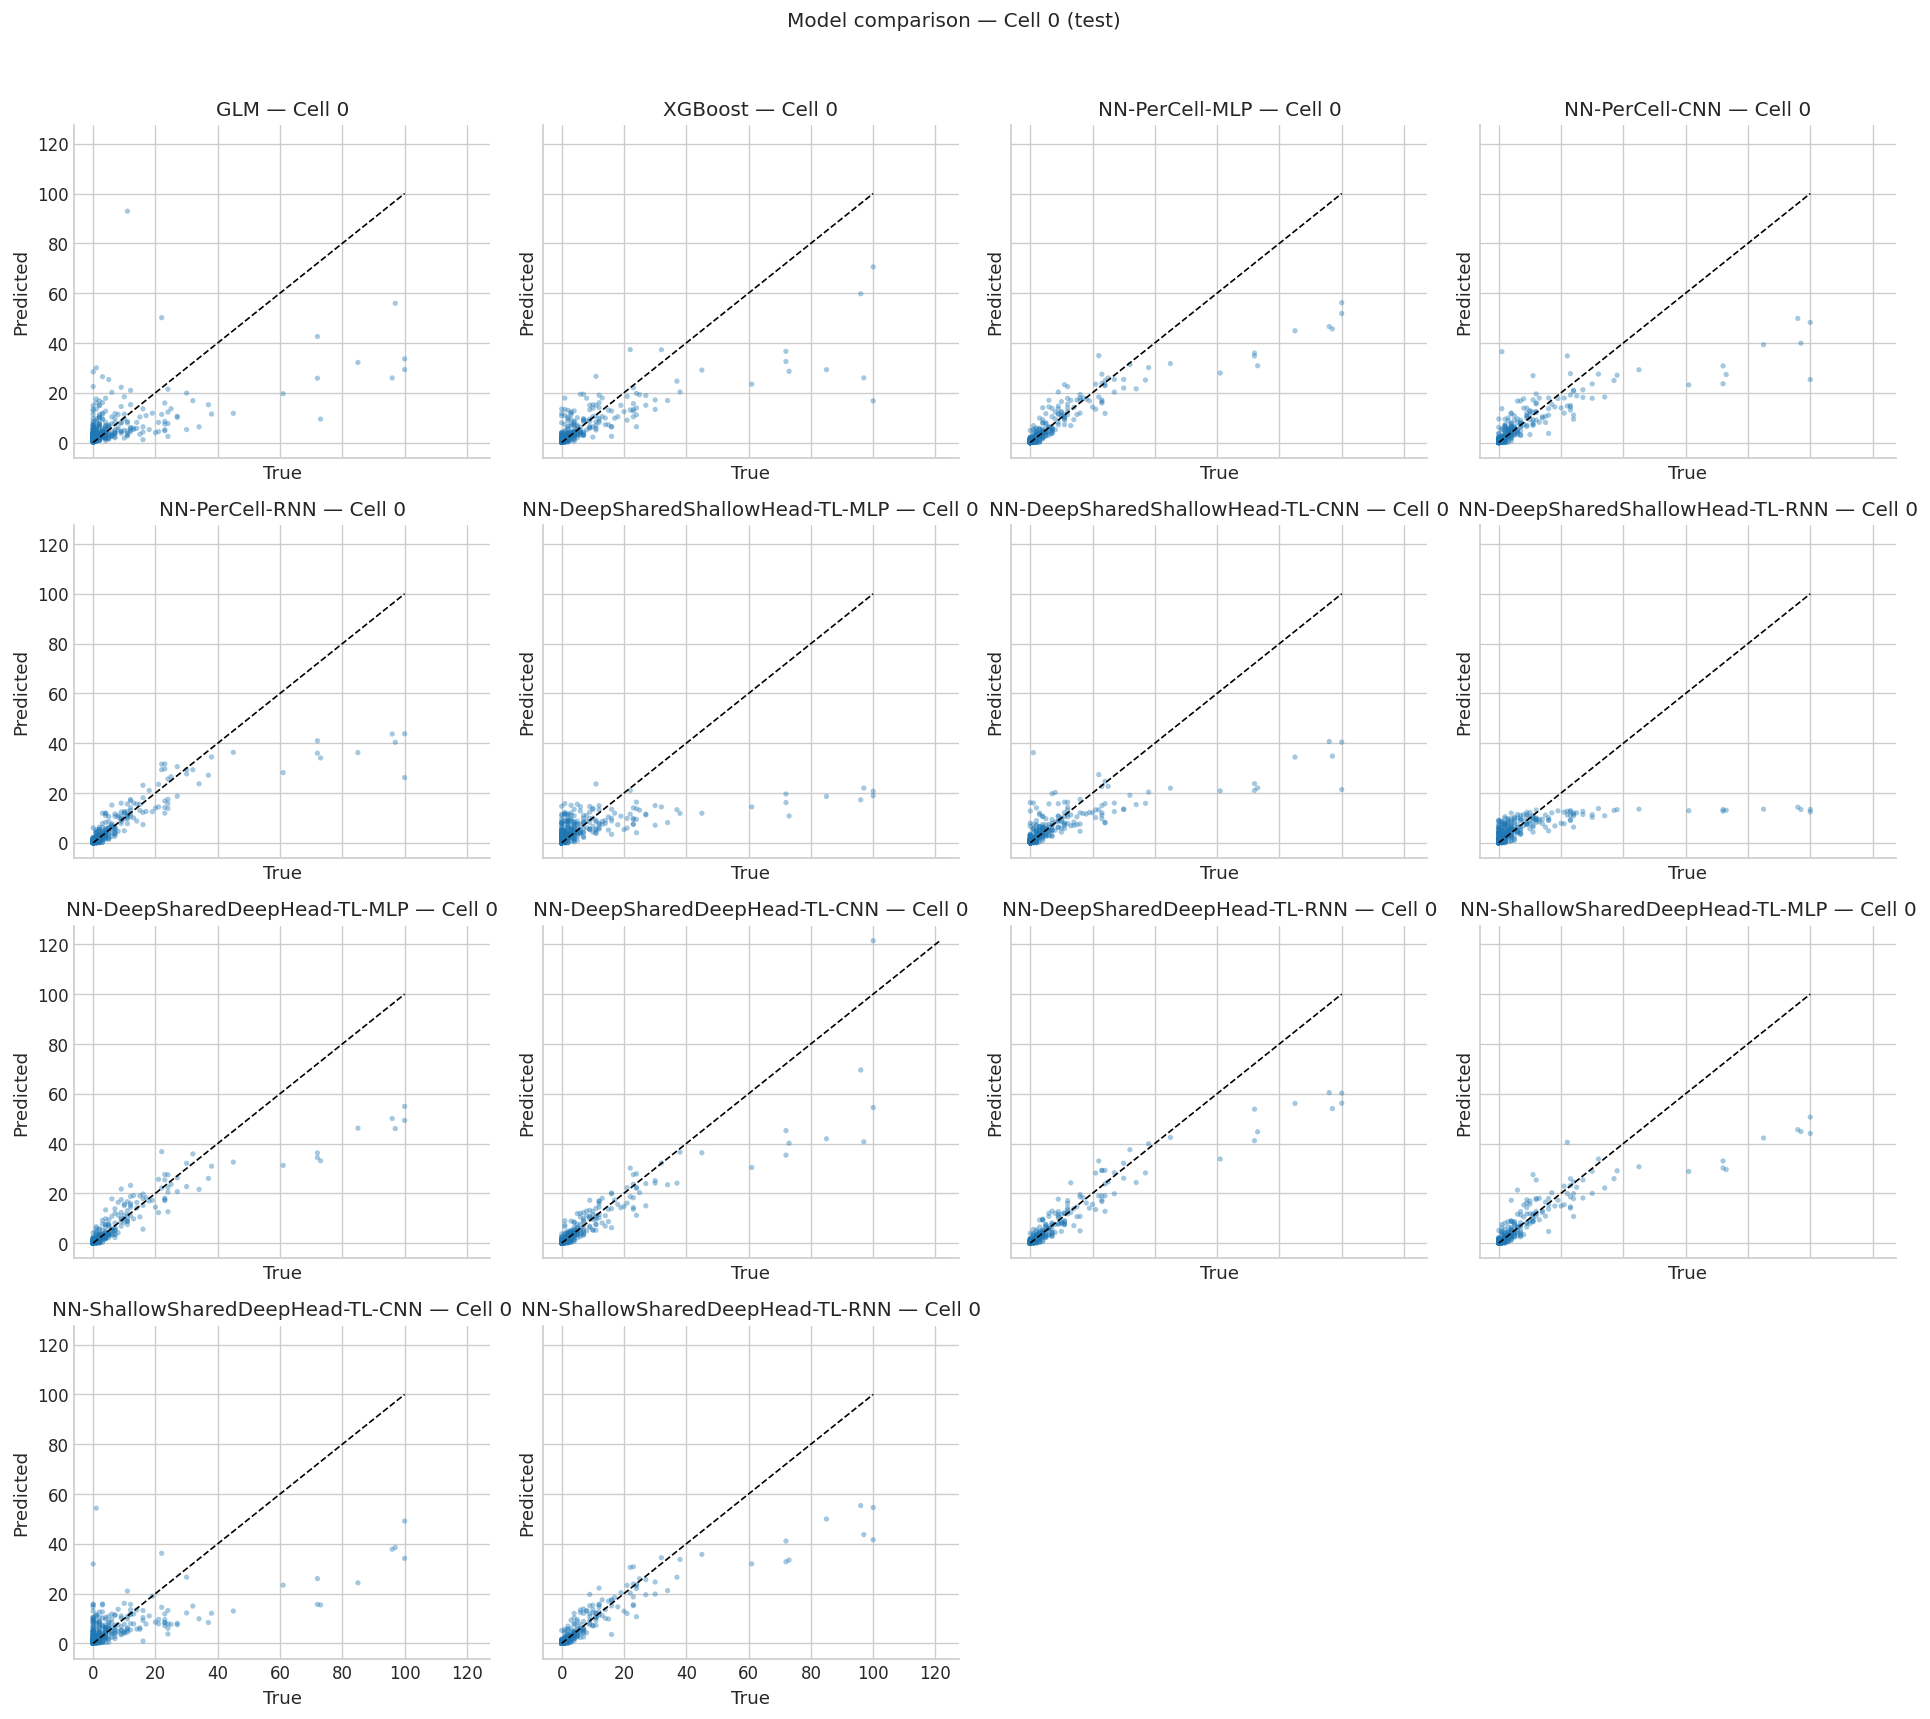

In [35]:
compare_models_for_cell(model_results_gs, cell=0, split="test")

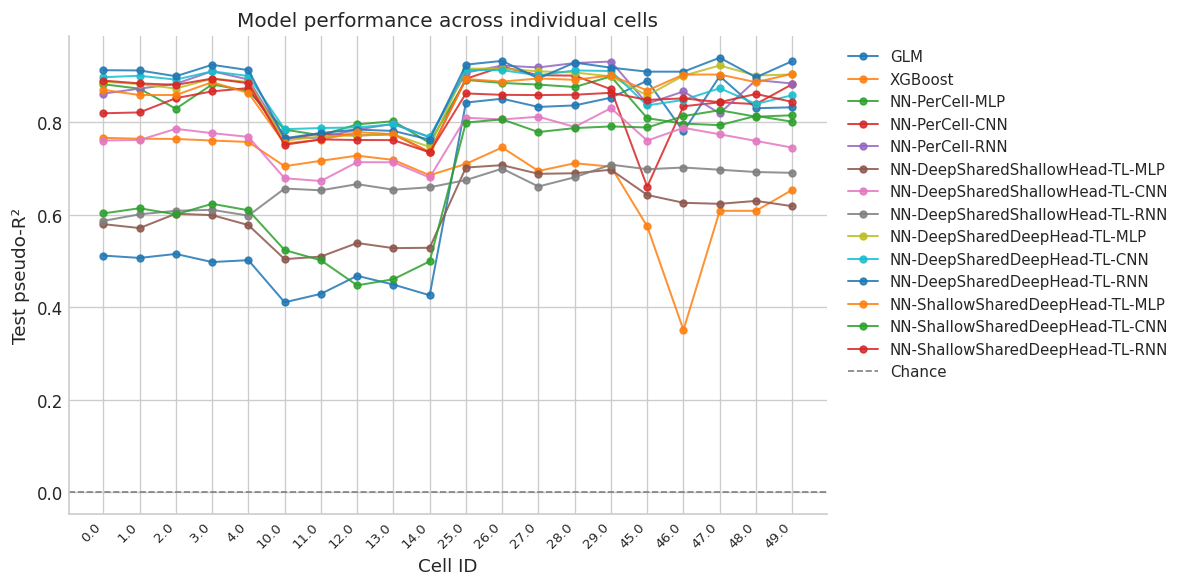

In [36]:
compare_r2_across_cells(model_results_gs, split="test")

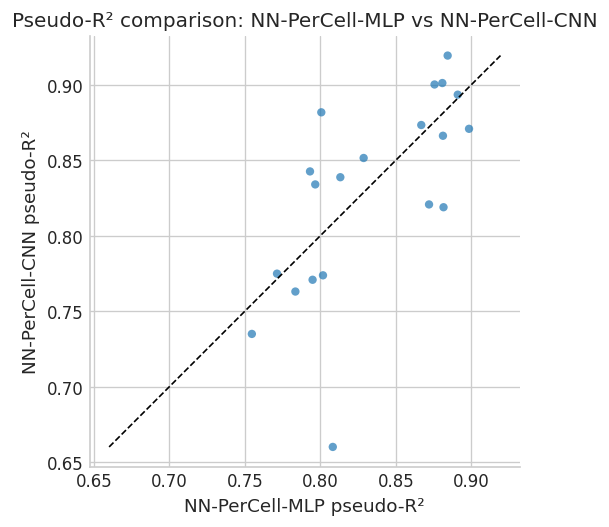

In [37]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [38]:
# No-grid-search results for all models
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (percell_results["MLP"]["NoGS"]["results"], "NN-PerCell-MLP (No GS)"),
    (percell_results["CNN"]["NoGS"]["results"], "NN-PerCell-CNN (No GS)"),
    (percell_results["RNN"]["NoGS"]["results"], "NN-PerCell-RNN (No GS)"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN (No GS)",
    ),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [39]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_nogs = pd.DataFrame(data_rows)
df_test_perf_nogs

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell-MLP (No GS),NN-PerCell-CNN (No GS),NN-PerCell-RNN (No GS),NN-DeepSharedShallowHead-TL-MLP (No GS),NN-DeepSharedShallowHead-TL-CNN (No GS),NN-DeepSharedShallowHead-TL-RNN (No GS),NN-DeepSharedDeepHead-TL-MLP (No GS),NN-DeepSharedDeepHead-TL-CNN (No GS),NN-DeepSharedDeepHead-TL-RNN (No GS),NN-ShallowSharedDeepHead-TL-MLP (No GS),NN-ShallowSharedDeepHead-TL-CNN (No GS),NN-ShallowSharedDeepHead-TL-RNN (No GS)
0,0.0,0.495828,0.787478,0.893040,0.867123,0.870030,0.557775,0.661593,0.307851,0.815853,0.838093,0.616135,0.625056,0.298010,0.598782
1,1.0,0.491330,0.776923,0.860431,0.878646,0.877143,0.574929,0.674349,0.346858,0.803484,0.839723,0.593509,0.608398,0.296483,0.610587
2,2.0,0.487759,0.777255,0.898519,0.862067,0.879220,0.581005,0.658327,0.315764,0.816972,0.818765,0.607160,0.616302,0.289123,0.629241
3,3.0,0.481392,0.781882,0.878529,0.875266,0.885301,0.571394,0.678459,0.327624,0.821874,0.839446,0.609852,0.635108,0.299197,0.626014
4,4.0,0.472272,0.763104,0.828087,0.874012,0.870070,0.578282,0.655112,0.326243,0.811906,0.838727,0.626790,0.639715,0.292417,0.618771
5,10.0,0.413206,0.690789,0.787267,0.744805,0.761073,0.528661,0.488682,0.294989,0.627647,0.677351,0.439712,0.596561,0.224187,0.615684
6,11.0,0.439885,0.710068,0.783759,0.765926,0.773868,0.529778,0.512873,0.368117,0.644051,0.699248,0.442184,0.596437,0.225918,0.613831
7,12.0,0.454806,0.729184,0.806965,0.769659,0.789701,0.551791,0.435798,0.340028,0.659423,0.697218,0.435094,0.628132,0.202013,0.587756
8,13.0,0.438039,0.709677,0.800454,0.758884,0.787117,0.543946,0.546490,0.335873,0.648914,0.698184,0.444723,0.608494,0.210204,0.591160
9,14.0,0.431220,0.694672,0.756711,0.741534,0.764318,0.551588,0.465409,0.347554,0.634661,0.671949,0.432062,0.604790,0.227848,0.591019


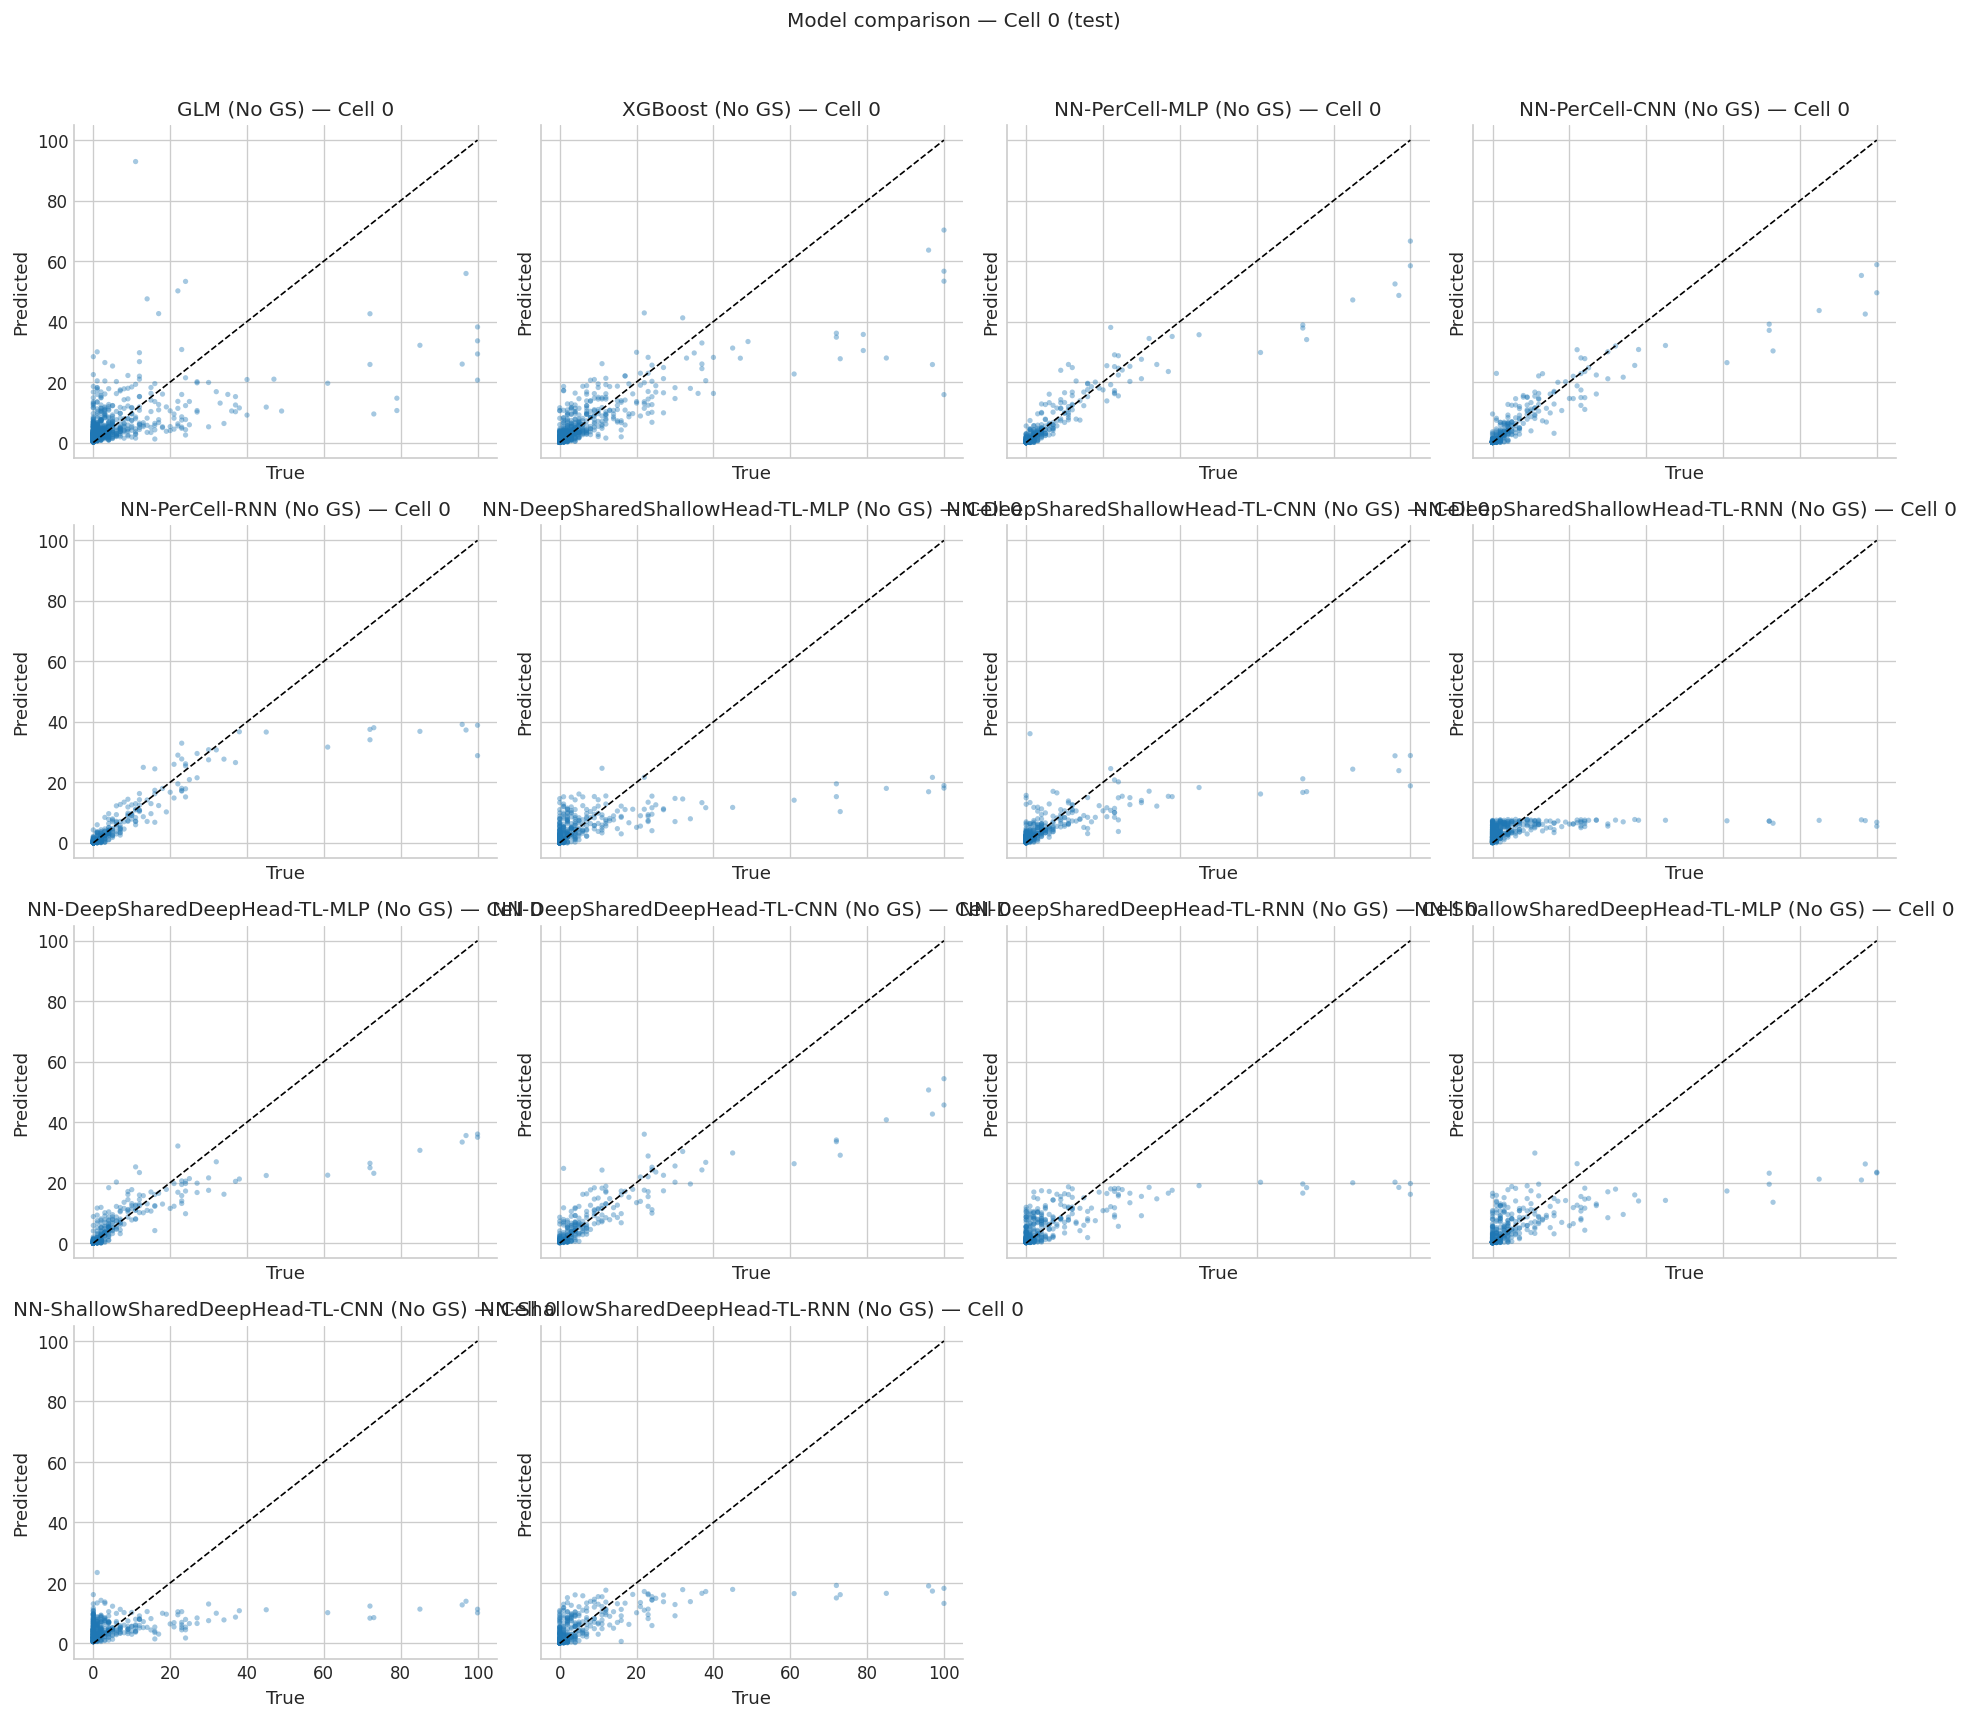

In [40]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

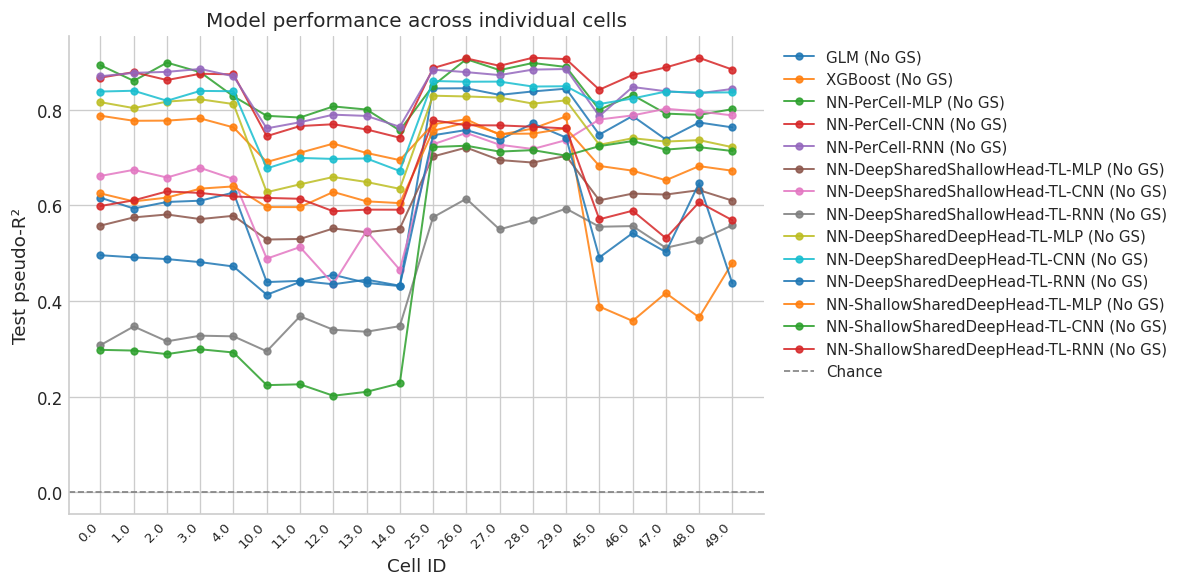

In [41]:
compare_r2_across_cells(model_results_nogs, split="test")

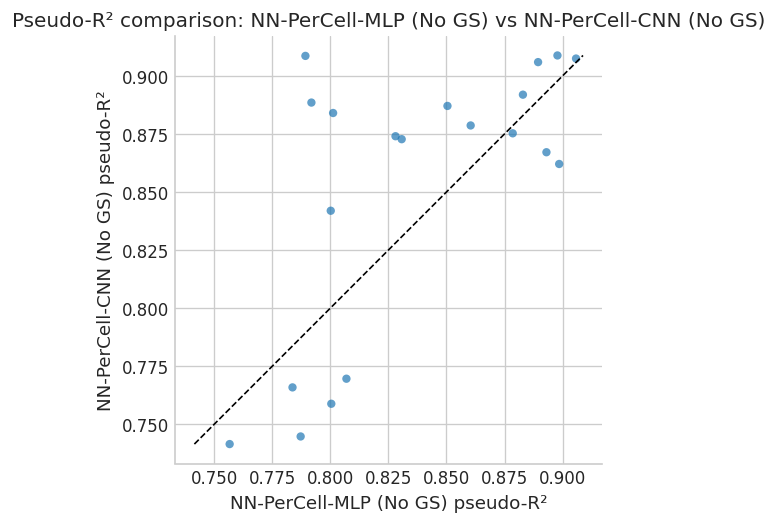

In [42]:
compare_models_pairwise_r2(
    model_results_nogs,
    "NN-PerCell-MLP (No GS)",
    "NN-PerCell-CNN (No GS)",
)

In [43]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
    pairwise_pairs=[
        # Core scientific comparisons
        ("GLM", "NN-PerCell-MLP"),
        ("GLM", "NN-DeepSharedDeepHead-TL-MLP"),
        ("NN-PerCell-MLP", "NN-DeepSharedDeepHead-TL-MLP"),
        # Architecture comparison within TL
        ("NN-DeepSharedShallowHead-TL-MLP", "NN-DeepSharedDeepHead-TL-MLP"),
    ],
    example_cells=[0, 3],  # two cells that show interesting prediction quality
)
print(f"Generated {len(saved_paths)} focused plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 9 focused plots
  ..\resources\results\simulated\journal\pairwise_GLM_vs_NN-DeepSharedDeepHead-TL-MLP.png
  ..\resources\results\simulated\journal\pairwise_NN-PerCell-MLP_vs_NN-DeepSharedDeepHead-TL-MLP.png
  ..\resources\results\simulated\journal\pairwise_NN-DeepSharedShallowHead-TL-MLP_vs_NN-DeepSharedDeepHead-TL-MLP.png
  ..\resources\results\simulated\journal\cell_0.png
  ..\resources\results\simulated\journal\cell_3.png


In [44]:
# Covariate overview for simulated data
# The simulated data has 5 covariates and 120 trials per cell
fig_cov_sim = plot_covariate_trial(
    X,
    Y,
    cell_ids,
    cell_idx=0,  # first simulated cell
    trial_idx=60,  # mid-session trial
    covariate_names=COVARIATE_NAMES_SIMULATED,
    trials_per_cell=120,  # simulated data uses 120 trials
    bin_duration_ms=50,
    title="Simulated data: covariates and spike counts (Cell 0, Trial 60)",
)
fig_cov_sim.savefig(
    f"{BASE_RESULTS_DIR}/journal/figure1_covariate_trial_simulated.pdf",
    dpi=300,
    bbox_inches="tight",
)

c:\Users\Temitope Shitta\BioInfo Projects\BIOL61230_poisson_neural_net\src\visualisation.py:879: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [45]:
# Figure 3: baseline and per-cell neural network comparison on simulated data
# This shows the progression GLM → XGBoost → per-cell NNs

# Build a focused list — GS versions only, clearest story
fig3_models = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
]

fig3 = plot_r2_comparison_boxplot(
    fig3_models,
    split="test",
    title="Simulated data: baseline vs per-cell neural network performance",
)
fig3.savefig(
    f"{BASE_RESULTS_DIR}/journal/figure3_percell_comparison.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
# Figure 4: transfer learning architecture comparison on simulated data
# This is the headline result showing DeepSharedDeepHead dominance

fig4_models = [
    # Include per-cell MLP as the non-TL reference point
    (percell_results["MLP"]["GS"]["results"], "PerCell-MLP"),
    # All three TL architectures with MLP extractor
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "TL-DeepShared\nShallowHead-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "TL-DeepShared\nDeepHead-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "TL-ShallowShared\nDeepHead-MLP",
    ),
    # Best TL architecture with CNN and RNN for robustness check
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "TL-DeepShared\nDeepHead-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "TL-DeepShared\nDeepHead-RNN",
    ),
]

fig4 = plot_r2_comparison_boxplot(
    fig4_models,
    split="test",
    title="Simulated data: transfer learning architecture comparison",
    figsize=(10, 5),  # slightly wider to accommodate the labels
)
fig4.savefig(
    f"{BASE_RESULTS_DIR}/journal/figure4_tl_comparison.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [47]:
# Companion to Figure 3: pseudo-R² distribution histogram
# Shows the shift in performance distribution as model complexity increases
fig_hist_sim = plot_r2_histogram(
    [
        (glm_results["results"], "GLM"),
        (xgboost_results["results"], "XGBoost"),
        (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
        (
            tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
            "TL-DeepSharedDeepHead-MLP",
        ),
    ],
    split="test",
    bins=15,  # fewer bins appropriate for only 20 cells
    title="Distribution of test pseudo-R² (simulated data)",
)
fig_hist_sim.savefig(
    f"{BASE_RESULTS_DIR}/journal/figure3_r2_histogram_simulated.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [48]:
# Exploratory: which cells are hard to predict, and do NNs help uniformly?
fig_sorted = compare_r2_across_cells(
    [
        (glm_results["results"], "GLM"),
        (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
        (
            tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
            "TL-DeepSharedDeepHead-MLP",
        ),
    ],
    split="test",
    sort_by="GLM",  # sort cells from hardest to easiest for the GLM
)
fig_sorted.savefig(
    f"{BASE_RESULTS_DIR}/journal/r2_sorted_simulated.pdf", dpi=300, bbox_inches="tight"
)